<a href="https://colab.research.google.com/github/kgm10027/-/blob/main/CNN%EC%B5%9C%EC%A0%81%ED%99%94_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"준비 완료! 현재 사용 장치: {device}")

준비 완료! 현재 사용 장치: mps


Part 1: 라이브러리 임포트 및 CIFAR-100 데이터 준비

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import urllib.request
from PIL import Image

# 1. CIFAR-100 전처리 (학습용: 증강 포함 / 정규화 수치 CIFAR-100에 맞게 수정)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# 2. 데이터셋 로드
train_dataset = datasets.CIFAR100('./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, 
                          num_workers=4, pin_memory=False, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, 
                          num_workers=4, pin_memory=False, persistent_workers=True)

# CIFAR-100의 100개 클래스 자동 로드
classes = train_dataset.classes

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")
print(f"클래스 개수: {len(classes)}개")

학습 데이터: 50000장
테스트 데이터: 10000장
클래스 개수: 100개


**Part 2: 모델 정의 및 학습**

In [3]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: 레이어 2겹으로 정교한 특징 추출
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  # <-- [추가] 2번째 Conv
            nn.BatchNorm2d(32),               # <-- [추가]
            nn.ReLU(),                        # <-- [추가]
            nn.MaxPool2d(2, 2)
        )

        # Block 2: 레이어 2겹
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  # <-- [추가] 2번째 Conv
            nn.BatchNorm2d(64),               # <-- [추가]
            nn.ReLU(),                        # <-- [추가]
            nn.MaxPool2d(2, 2)
        )

        # Block 3: 레이어 2겹
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), # <-- [추가] 2번째 Conv
            nn.BatchNorm2d(128),               # <-- [추가]
            nn.ReLU(),                         # <-- [추가]
            nn.MaxPool2d(2, 2)
        )

        # 분류기 (GAP 적용으로 파라미터 다이어트 및 과적합 방지)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # <-- [추가] 공간 정보를 1x1로 요약 (GAP)
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 100)           # <-- 기존의 무거운 Linear(2048, 512)를 가볍게 대체
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CIFAR_CNN().to(device)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset) * 100

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset) * 100

EPOCHS = 100
best_acc = 0

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step()
    
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar100_model.pth')

print(f"\n최고 테스트 정확도: {best_acc:.2f}%")

Epoch  1/100 | Train Loss: 4.0943 Acc: 7.2% | Test Loss: 3.7316 Acc: 11.2%
Epoch  2/100 | Train Loss: 3.5178 Acc: 15.0% | Test Loss: 3.3834 Acc: 17.4%
Epoch  3/100 | Train Loss: 3.1888 Acc: 20.9% | Test Loss: 3.0313 Acc: 24.2%
Epoch  4/100 | Train Loss: 2.9600 Acc: 25.0% | Test Loss: 2.8332 Acc: 27.8%
Epoch  5/100 | Train Loss: 2.8007 Acc: 27.9% | Test Loss: 2.7946 Acc: 28.6%
Epoch  6/100 | Train Loss: 2.6748 Acc: 30.3% | Test Loss: 2.5756 Acc: 33.2%
Epoch  7/100 | Train Loss: 2.5779 Acc: 32.6% | Test Loss: 2.3670 Acc: 37.1%
Epoch  8/100 | Train Loss: 2.4925 Acc: 34.3% | Test Loss: 2.2404 Acc: 39.7%
Epoch  9/100 | Train Loss: 2.4115 Acc: 36.2% | Test Loss: 2.4385 Acc: 36.2%
Epoch 10/100 | Train Loss: 2.3463 Acc: 37.6% | Test Loss: 2.2510 Acc: 40.3%
Epoch 11/100 | Train Loss: 2.2911 Acc: 38.6% | Test Loss: 2.1495 Acc: 41.7%
Epoch 12/100 | Train Loss: 2.2412 Acc: 40.1% | Test Loss: 2.0533 Acc: 43.5%
Epoch 13/100 | Train Loss: 2.1933 Acc: 41.3% | Test Loss: 2.0932 Acc: 43.3%
Epoch 14/100 

**Part 3: 모델 분석 및 시각화 (특징 맵 & 혼동 행렬)**

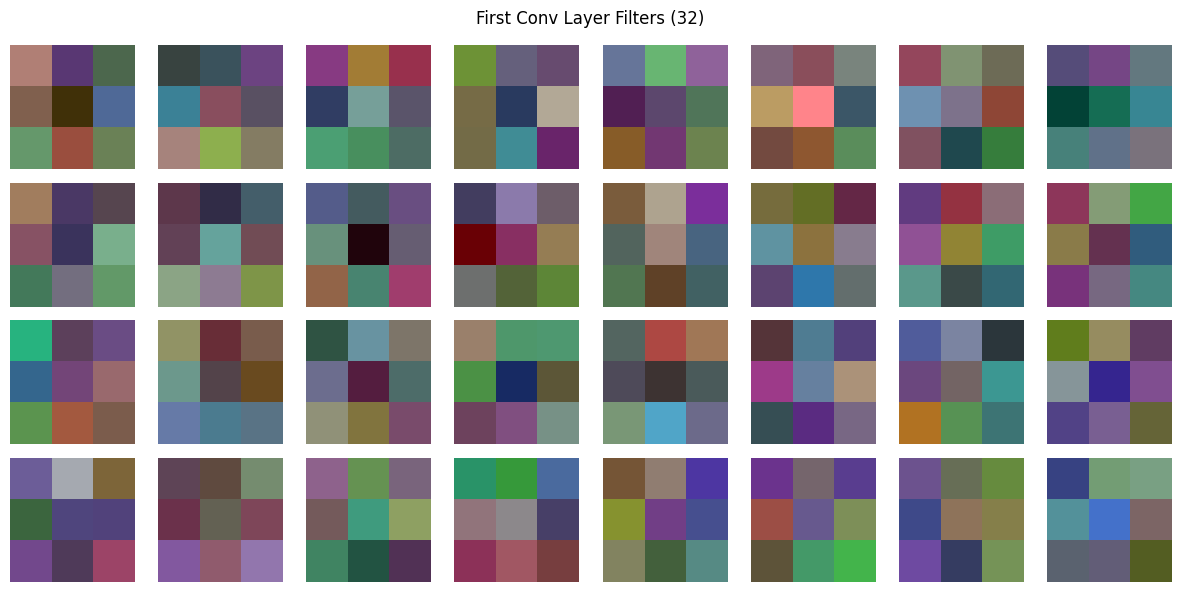

In [4]:
# 1. 첫 번째 Conv 레이어 가중치 시각화
weights = model.block1[0].weight.data.cpu()
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        filt = weights[i].permute(1, 2, 0).numpy()
        ax.imshow(filt)
    ax.axis('off')
plt.suptitle("First Conv Layer Filters (32)", fontsize=12)
plt.tight_layout()
plt.show()

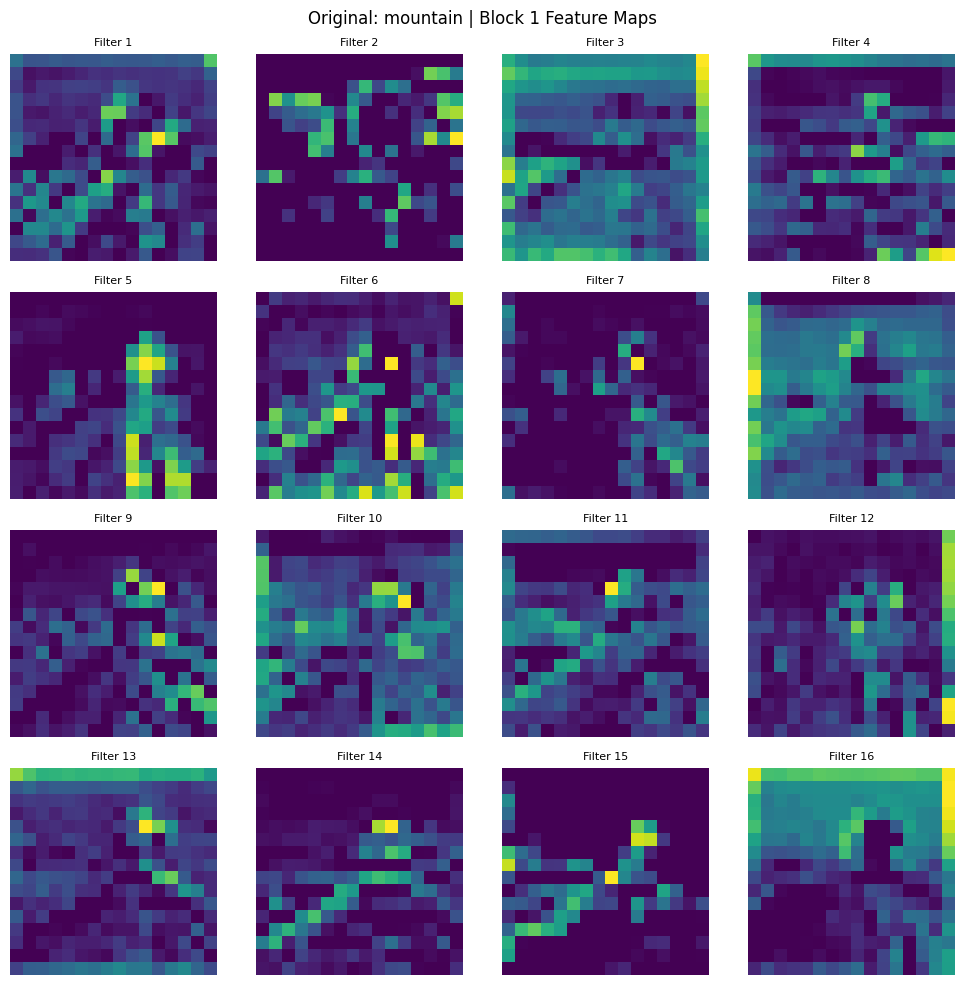

In [5]:
# 2. 특정 이미지 특징 맵 시각화
image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)

feature_maps = {}
def hook_fn(module, input, output):
    feature_maps['block1'] = output.detach().cpu()
hook = model.block1.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(image_tensor)
hook.remove()

fmaps = feature_maps['block1'][0]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis('off')
plt.suptitle(f"Original: {classes[label]} | Block 1 Feature Maps", fontsize=12)
plt.tight_layout()
plt.show()

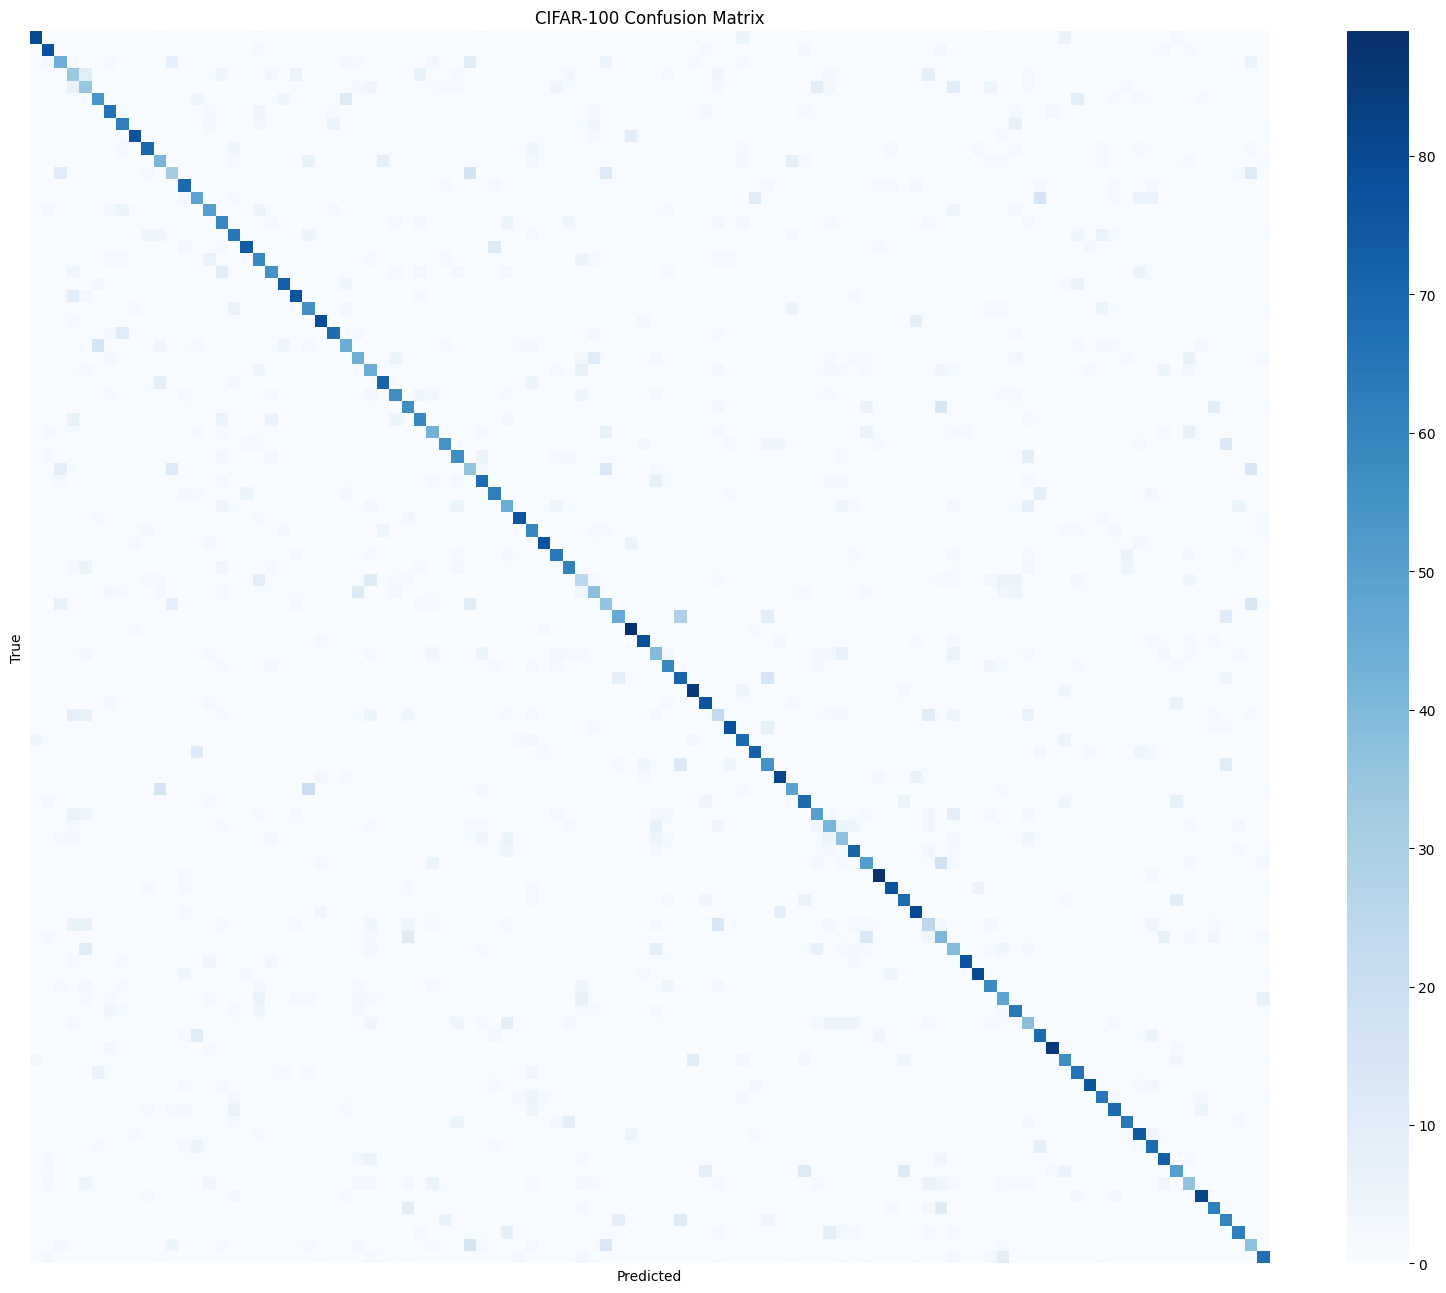

In [6]:
# 3. 혼동 행렬 (크기를 키우고 숫자는 생략하여 전체적인 패턴만 확인)
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16)) # 100개 클래스라 크기를 대폭 키움
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False) # 글씨 겹침 방지
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CIFAR-100 Confusion Matrix')
plt.show()

**Part 4: 임의의 사진 입력 및 예측 (새로 추가된 기능)**

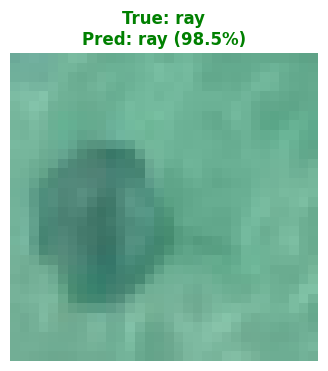

🎉 정답입니다! (실제: ray / 예측: ray)


In [10]:
import random

# Part 4: 무작위 테스트 데이터 자동 예측
def predict_random_cifar_image(model, dataset, device, classes):
    model.eval()

    # 1. 테스트 데이터셋에서 무작위로 인덱스 하나 뽑기
    idx = random.randint(0, len(dataset) - 1)
    image_tensor, true_label_idx = dataset[idx]
    true_class = classes[true_label_idx]

    # 2. 모델 예측 (배치 차원 추가: [3, 32, 32] -> [1, 3, 32, 32])
    img_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        probabilities = F.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, dim=0)

    predicted_class = classes[predicted_idx.item()]
    confidence_score = confidence.item() * 100

    # 3. 화면에 보여주기 위한 이미지 색상 복원 (Unnormalize)
    # 현재 텐서는 학습을 위해 색상이 변형(정규화)되어 있으므로 원래 색으로 되돌려줍니다.
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    img_show = image_tensor.cpu() * std + mean

    # 파이토치 텐서 [C, H, W]를 Matplotlib용 [H, W, C]로 변경
    img_show = img_show.clamp(0, 1).permute(1, 2, 0).numpy()

    # 4. 결과 출력
    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)

    # 모델이 정답을 맞추면 초록색, 틀리면 빨간색으로 제목 표시
    title_color = 'green' if true_class == predicted_class else 'red'
    plt.title(f"True: {true_class}\nPred: {predicted_class} ({confidence_score:.1f}%)",
              color=title_color, fontweight='bold')
    plt.axis('off')
    plt.show()

    if true_class == predicted_class:
        print(f"🎉 정답입니다! (실제: {true_class} / 예측: {predicted_class})")
    else:
        print(f"😢 틀렸습니다. (실제: {true_class} / 예측: {predicted_class})")

# --- 테스트 실행 ---
# 이 셀을 여러 번 실행해 보세요! 매번 다른 사진을 알아서 가져와서 맞춥니다.
predict_random_cifar_image(model, test_dataset, device, classes)